# ch302 — The Perceptron

## 1. What the perceptron computes

The perceptron is the atomic unit of neural computation. It takes a vector of inputs,
computes a weighted sum, and passes the result through a threshold function:

$$
\hat{y} = \mathbf{1}[\mathbf{w}^\top \mathbf{x} + b > 0]
$$

where $\mathbf{w} \in \mathbb{R}^d$ are weights, $b \in \mathbb{R}$ is the bias, and
$\mathbf{1}[\cdot]$ is the indicator function.

The geometric interpretation is immediate: $\mathbf{w}^\top \mathbf{x} + b = 0$ defines
a hyperplane in $\mathbb{R}^d$. The perceptron assigns class 1 to everything on one side,
class 0 to the other. It is a **linear classifier**.

*(Dot product geometry introduced in ch131–ch132. Hyperplanes are the generalisation of lines
and planes from ch099–ch101.)*

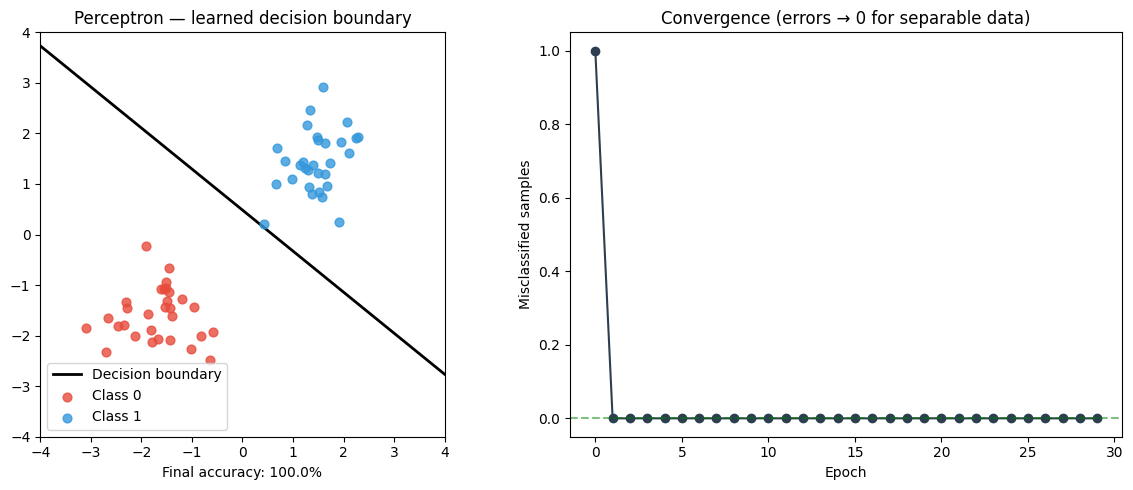

Converged in 2 epochs
Learned weights: w=[1.67463731 2.06193869], b=-1.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


class Perceptron:
    """Binary perceptron with the original Rosenblatt update rule."""

    def __init__(self, n_features: int, lr: float = 1.0, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.w = rng.normal(0, 0.01, n_features)
        self.b = 0.0
        self.lr = lr

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return 0/1 predictions for each row of X."""
        return (X @ self.w + self.b > 0).astype(int)

    def fit(self, X: np.ndarray, y: np.ndarray, n_epochs: int = 20) -> list:
        """Train using the perceptron update rule. Returns per-epoch error counts."""
        errors_per_epoch = []
        for _ in range(n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = int(xi @ self.w + self.b > 0)
                if y_hat != yi:
                    # Perceptron update: move decision boundary toward correct side
                    self.w += self.lr * (yi - y_hat) * xi
                    self.b += self.lr * (yi - y_hat)
                    errors += 1
            errors_per_epoch.append(errors)
        return errors_per_epoch


# --- Linearly separable dataset ---
rng = np.random.default_rng(7)
n = 60
X0 = rng.multivariate_normal([-1.5, -1.5], [[0.4, 0], [0, 0.4]], n // 2)
X1 = rng.multivariate_normal([1.5, 1.5], [[0.4, 0], [0, 0.4]], n // 2)
X = np.vstack([X0, X1])
y = np.array([0] * (n // 2) + [1] * (n // 2))

perc = Perceptron(n_features=2, lr=1.0)
errors = perc.fit(X, y, n_epochs=30)

# --- Plot: decision boundary + convergence ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

xx = np.linspace(-4, 4, 300)
# w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1]
if abs(perc.w[1]) > 1e-8:
    yy = -(perc.w[0] * xx + perc.b) / perc.w[1]
    ax1.plot(xx, yy, 'k-', lw=2, label='Decision boundary')

colors = ['#e74c3c', '#3498db']
for cls in [0, 1]:
    mask = y == cls
    ax1.scatter(X[mask, 0], X[mask, 1], color=colors[cls], s=40,
                alpha=0.8, label=f'Class {cls}', zorder=3)

ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.set_aspect('equal')
ax1.set_title('Perceptron — learned decision boundary')
ax1.legend()
acc = (perc.predict(X) == y).mean()
ax1.set_xlabel(f'Final accuracy: {acc:.1%}')

ax2.plot(errors, 'o-', color='#2c3e50')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Misclassified samples')
ax2.set_title('Convergence (errors → 0 for separable data)')
ax2.axhline(0, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ch302_perceptron.png', dpi=120)
plt.show()
print(f"Converged in {errors.index(0) + 1 if 0 in errors else '>30'} epochs")
print(f"Learned weights: w={perc.w}, b={perc.b:.4f}")

## 2. The perceptron update rule — why it works

When sample $(x, y)$ is misclassified:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta (y - \hat{y}) \mathbf{x}, \quad
b \leftarrow b + \eta (y - \hat{y})
$$

For a false negative ($y=1, \hat{y}=0$): we add $\mathbf{x}$ to $\mathbf{w}$, making
$\mathbf{w}^\top \mathbf{x}$ larger, pushing the prediction toward 1.

For a false positive ($y=0, \hat{y}=1$): we subtract $\mathbf{x}$ from $\mathbf{w}$.

**Perceptron Convergence Theorem:** If the data is linearly separable, the perceptron
converges in finite steps. If not, it never converges — it cycles. This is the fundamental
limitation that XOR famously exposed.

---

## 3. The XOR failure

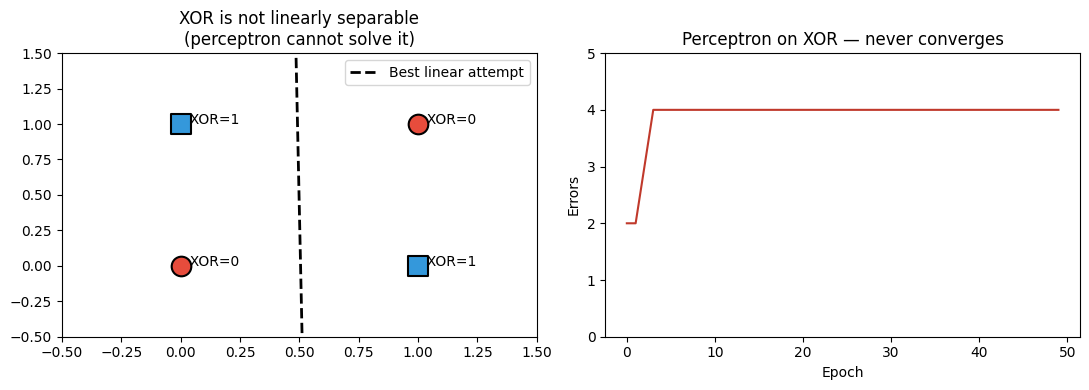

Final accuracy on XOR: 0.5

The fix: stack perceptrons into layers — covered in ch303.


In [2]:
# XOR: no linear boundary exists
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])  # XOR labels

perc_xor = Perceptron(n_features=2, lr=1.0, seed=3)
errors_xor = perc_xor.fit(X_xor, y_xor, n_epochs=50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

markers = ['o', 's']
for i, (xi, yi) in enumerate(zip(X_xor, y_xor)):
    ax1.scatter(xi[0], xi[1], color=colors[yi], s=200, marker=markers[yi],
                zorder=5, edgecolors='black', linewidths=1.5)
    ax1.annotate(f'  XOR={yi}', xi, fontsize=10)

xx = np.linspace(-0.5, 1.5, 200)
if abs(perc_xor.w[1]) > 1e-8:
    yy = -(perc_xor.w[0] * xx + perc_xor.b) / perc_xor.w[1]
    ax1.plot(xx, yy, 'k--', lw=2, label='Best linear attempt')
ax1.set_xlim(-0.5, 1.5)
ax1.set_ylim(-0.5, 1.5)
ax1.set_title('XOR is not linearly separable\n(perceptron cannot solve it)')
ax1.legend()

ax2.plot(errors_xor, color='#c0392b')
ax2.set_title('Perceptron on XOR — never converges')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Errors')
ax2.set_ylim(0, 5)

plt.tight_layout()
plt.savefig('ch302_xor_failure.png', dpi=120)
plt.show()
print("Final accuracy on XOR:", (perc_xor.predict(X_xor) == y_xor).mean())
print("\nThe fix: stack perceptrons into layers — covered in ch303.")

## 4. From perceptron to neuron

The modern usage replaces the hard threshold $\mathbf{1}[z > 0]$ with a smooth activation
function $\sigma(z)$. This is critical: the hard threshold has zero gradient almost everywhere,
making gradient-based training impossible.

$$
\text{Perceptron:} \quad \hat{y} = \mathbf{1}[\mathbf{w}^\top\mathbf{x} + b > 0]
$$
$$
\text{Neuron:} \quad \hat{y} = \sigma(\mathbf{w}^\top\mathbf{x} + b)
$$

Activation functions are explored in depth in ch309. The chain rule that enables gradient
computation through $\sigma$ is formalised in ch306.

---

## 5. Summary

- The perceptron computes a weighted sum then applies a threshold — it is a linear classifier.
- The update rule moves the decision boundary toward the misclassified point.
- The Perceptron Convergence Theorem guarantees convergence iff data is linearly separable.
- XOR is the canonical failure: it requires a nonlinear boundary, forcing us toward multilayer nets.

---

## 6. Forward and backward references

**Used here:** dot product *(ch131)*, hyperplanes from linear algebra *(ch161)*,
linear classifiers *(ch287)*.

**This will reappear in ch303 — Multilayer Networks**, where stacking two perceptron-like
layers solves XOR, and in ch306 — Backpropagation, where the hard threshold is replaced
by a differentiable activation to enable learning.